# Project 2 — Predicting Heart Disease 


Dataset: `heart-disease.csv` (303 patients, 13 features, target = 0/1). Loads from a URL.


## 1. Business Problem

A clinic wants a decision-support tool: given a patient's measurements, flag whether they likely **have heart disease (1)** or **not (0)**.

- **Binary classification** — the target is one of two categories (and we get a *probability*).
- **Mistakes aren't equal:** missing a sick patient (false negative) is far worse than a false alarm.

## 2. Explore the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

heart_disease = pd.read_csv("../data/heart-disease.csv")
heart_disease.head()

In [2]:
heart_disease.shape          # 303 patients, 14 columns (13 features + target)

(303, 14)

In [3]:
heart_disease.dtypes         # all numeric already

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [4]:
heart_disease.isna().sum()   # check for missing values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
heart_disease["target"].value_counts()   # class balance: how many 1s vs 0s?

target
1    165
0    138
Name: count, dtype: int64

**Class balance matters:** if 99% of patients were healthy, a model that always says 'healthy' scores 99% and catches nobody. We check balance *before* trusting accuracy.

## 3. Data Preparation & Pipeline

`target` is y, everything else is X. Data is clean, but we still wrap preprocessing in a **Pipeline** — the professional default, and it makes saving + future predictions clean.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Even on clean data, a pipeline is the professional default.
# (If a future patient's data has a blank cell, this imputer handles it.)
# The model gets filled in the next section.

## 4. Train/Test Split

Same principle as Project 1 — grade the model on patients it never trained on; the pipeline fits on train only.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((227, 13), (76, 13), (227,), (76,))

## 5. Logistic Regression Model

**Logistic Regression** classifies (despite the name): it computes a weighted score, squashes it through an S-curve into a **probability 0-1**, then a **decision threshold** (default 0.5) turns that into a class. In medicine we often *lower* the threshold to catch more sick patients.

In [8]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000))  # max_iter so it converges
])

model.fit(X_train, y_train)
model.score(X_test, y_test)   # for a classifier, .score() = accuracy

c:\Users\Souad Khalifeh\Desktop\AI_Builders_Data_Analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8552631578947368

## 6. Predictions: predict vs predict_proba

- `predict()` -> the **decision**: 0 or 1.
- `predict_proba()` -> the **confidence**: probability of each class. `predict()` is just `predict_proba()` through the 0.5 threshold.

In [10]:
# Hard decisions
model.predict(X_test[:5])

array([0, 0, 1, 0, 1])

In [11]:
# Confidence behind those decisions - two columns: P(class 0), P(class 1)
model.predict_proba(X_test[:5])

array([[0.99851597, 0.00148403],
       [0.97054835, 0.02945165],
       [0.1799341 , 0.8200659 ],
       [0.96525362, 0.03474638],
       [0.14042347, 0.85957653]])

## 7. Evaluation (the centerpiece)

**Accuracy alone lies.** We need the full toolkit. Everything is built from the **confusion matrix**:

```
                  Predicted 0        Predicted 1
Actual 0      True Negative (TN)   False Positive (FP)   <- false alarm
Actual 1      False Negative (FN)  True Positive (TP)
                      ^ MISSED a sick patient - the dangerous one here
```

Scikit-Learn has multiple different implementations of plotting confusion matrices:
1. [`sklearn.metrics.ConfusionMatrixDisplay.from_estimator(estimator, X, y)`]- this takes a fitted estimator (like our `clf` model), features (`X`) and labels (`y`), it then uses the trained estimator to make predictions on `X` and compares the predictions to `y` by displaying a confusion matrix.
2. [`sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred)`] - this takes truth labels and predicted labels and compares them by displaying a confusion matrix.


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_preds = model.predict(X_test)
confusion_matrix(y_test, y_preds)

array([[23,  8],
       [ 3, 42]])

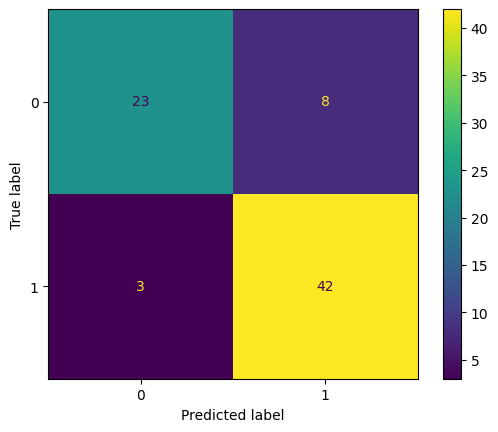

In [16]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds);

- **Accuracy** = `(TP+TN)/all`. Misleading on imbalanced data.
- **Precision** = `TP/(TP+FP)` — when it says 'disease', how often right? (few false alarms)
- **Recall** = `TP/(TP+FN)` — of the actually sick, how many caught? **Usually the key metric in disease detection.**
- **F1** = harmonic mean of precision & recall — one balanced number.

In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)

0.8552631578947368

The final major metric you should consider when evaluating a classification model is a classification report.

A classification report is more so a collection of metrics rather than a single one.

You can create a classification report using Scikit-Learn's [sklearn.metrics.classification_report`]

In [18]:
from sklearn.metrics import classification_report
# precision, recall, f1-score, support - for each class
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.88      0.74      0.81        31
           1       0.84      0.93      0.88        45

    accuracy                           0.86        76
   macro avg       0.86      0.84      0.85        76
weighted avg       0.86      0.86      0.85        76



It returns four columns: precision, recall, f1-score and support.

The number of rows will depend on how many different classes there are. But there will always be three rows labell accuracy, macro avg and weighted avg.

Each term measures something slightly different:
* **Precision** - Indicates the proportion of positive identifications (model predicted class `1`) which were actually correct. A model which produces no false positives has a precision of 1.0.
* **Recall** - Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.
* **F1 score** - A combination of precision and recall. A perfect model achieves an F1 score of 1.0.
* **Support** - The number of samples each metric was calculated on.
* **Accuracy** - The accuracy of the model in decimal form. Perfect accuracy is equal to 1.0, in other words, getting the prediction right 100% of the time.
* **Macro avg** - Short for macro average, the average precision, recall and F1 score between classes. Macro avg doesn't take class imbalance into effect. So if you do have class imbalances (more examples of one class than another), you should pay attention to this.
* **Weighted avg** - Short for weighted average, the weighted average precision, recall and F1 score between classes. Weighted means each metric is calculated with respect to how many samples there are in each class. This metric will favour the majority class (e.g. it will give a high value when one class out performs another due to having more samples).

When should you use each?

It can be tempting to base your classification models perfomance only on accuracy. And accuracy is a good metric to report, except when you have very imbalanced classes.

For example, let's say there were 10,000 people. And 1 of them had a disease. You're asked to build a model to predict who has it.

You build the model and find your model to be 99.99% accurate. Which sounds great!
...until you realise, all its doing is predicting no one has the disease, in other words all 10,000 predictions are false.

In this case, you'd want to turn to metrics such as precision, recall and F1 score.

### ROC Curve & AUC

The **ROC curve** sweeps the threshold from 0 to 1 and plots True Positive Rate (recall) vs False Positive Rate — the *whole* trade-off. **AUC** squashes it to one number: 1.0 = perfect, 0.5 = random guessing. Best shape hugs the top-left corner.

AUC: 0.904


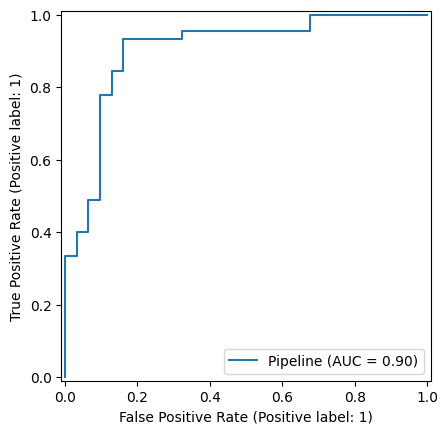

In [19]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# Probabilities of the positive class
y_probs = model.predict_proba(X_test)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_probs):.3f}")

RocCurveDisplay.from_estimator(estimator=model, X=X_test, y=y_test);

Ask yourself, although the model achieves 99.99% accuracy, is it useful?

To summarize:
* Accuracy is a good measure to start with if all classes are balanced (e.g. same amount of samples which are labelled with 0 or 1)
* Precision and recall become more important when classes are imbalanced.
* If false positive predictions are worse than false negatives, aim for higher precision.
* If false negative predictions are worse than false positives, aim for higher recall.

## 8. Improve the Model

Try another algorithm (`RandomForestClassifier`), then tune with `GridSearchCV` — and tune toward what matters (**recall**), not just accuracy.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier())
])
rf_model.fit(X_train, y_train)
print(f"LogReg accuracy: {model.score(X_test, y_test):.3f}")
print(f"Forest accuracy: {rf_model.score(X_test, y_test):.3f}")

LogReg accuracy: 0.855
Forest accuracy: 0.829


In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 4, 6],
}

# scoring="recall" - tune toward catching sick patients, not raw accuracy
gs = GridSearchCV(rf_model, param_grid, cv=5, scoring="recall", verbose=2)
gs.fit(X_train, y_train)
print(gs.best_params_)
print(f"Best CV recall: {gs.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.9s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   1.3s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   2.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   2.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   2.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   2.8s
[C

## 9. Save and Load the Model

Serialize the winning pipeline so the clinic's software can load and predict instantly.

In [22]:
import pickle
from joblib import dump, load

best_model = gs.best_estimator_

# pickle
pickle.dump(best_model, open("heart_disease_model.pkl", "wb"))
loaded = pickle.load(open("heart_disease_model.pkl", "rb"))
print(f"Loaded (pickle) accuracy: {loaded.score(X_test, y_test):.3f}")

# joblib
dump(best_model, "heart_disease_model.joblib")
loaded_joblib = load("heart_disease_model.joblib")
print(f"Loaded (joblib) accuracy: {loaded_joblib.score(X_test, y_test):.3f}")

Loaded (pickle) accuracy: 0.842
Loaded (joblib) accuracy: 0.842
